In [1]:
import arviz as az
import bambi as bmb
import pandas as pd

az.style.use("arviz-variat")
SEED = 9846

# Prior and likelihood sensitivity checks

Determining the sensitivity of the posterior to perturbations of the prior is an important part of building Bayesian models. The traditional way to assess the prior sensitivity is to compare the posterior obtained using two or more priors. For instance, we could compare the posterior computed using the automatic prior computed by Bambi against a prior that we have chosen based on our knowledge of the problem. Such comparisons can be done visually using a forest plot or some numerical summary. Ideally, we should report the results of this analysis, so that others can also understand how robust the model is to different prior choices.

The same approach can be applied to the likelihood, so we can discuss the sensitivity of the posterior to the likelihood, the prior or both.

In this notebook we will discuss a method proposed by [Kallioinen et al](https://link.springer.com/article/10.1007/s11222-023-10366-5) and implemented in ArviZ. The method offers visual and numerical diagnostics that can alert us of potential prior-data conflict or likelihood noninformativity. What makes this approach very practical is that we only need to fit a model once, and without explicitly modifying the prior or likelihood, we can assess the effect of changing them. This can be very useful when we do not have and explicit alternative prior or likelihood to compare against, or when we want a more systematic approach to assess the sensitivity of the posterior to the prior and likelihood. If you have reasons to explicitly compare results under different priors you should do so.

For details on how the method works you can read the [scientific paper](https://link.springer.com/article/10.1007/s11222-023-10366-5) or consult the [EABM guide](https://arviz-devs.github.io/EABM/Chapters/Sensitivity_checks.html) for an overview of the methods implemented in ArviZ.


## Body fat example

For this example we will use the bodyfat [data set](https://www.tandfonline.com/doi/full/10.1080/10691898.1996.11910505). The aim of the analysis is to predict an expensive and cumbersome water immersion measurement of body fat percentage (observed variable named `siri`) from a set of thirteen easier to measure characteristics, including age, height, weight, and circumferences of various body parts.

Let's start by loading the data and creating a `siri` variable for the response and a `body_fat` variable for the predictors. We center the predictors.


In [2]:
body_fat = pd.read_csv("data/body_fat.csv")

covars = body_fat.columns.difference(["siri"])
body_fat[covars] = body_fat[covars] - body_fat[covars].mean()

We are going to start by assuming that a resonable prior for all coefficients is Normal(0, 1). With that in mind, we will fit the following linear regression model:

$$
\begin{aligned}
    \beta_0 &\sim t_3(0, 9.2) \\
    \beta_k &\sim \mathcal{N}(0, 1) \\
    \sigma &\sim t_{3}^{+}(9.2) \\
    \mu &= β_0 + β X^T \\
    \text{siri} &\sim \mathcal{N}(\mu, \sigma)
\end{aligned}
$$

For the prior (and likelihood) sensitivity method to work we need to ensure that the `DataTree` object includes the groups log-prior and log-likelihood. 

In [3]:
priors = {
    "Intercept": bmb.Prior("StudentT", nu=3, mu=0, sigma=9.2),
    "sigma": bmb.Prior("HalfStudentT", nu=3, sigma=9.2),
    "common": bmb.Prior("Normal", mu=0, sigma=1),
}

model_bf_00 = bmb.Model(f"siri ~ {' + '.join(covars)}", data=body_fat, priors=priors)
dt_bf_00 = model_bf_00.fit(random_seed=SEED)
model_bf_00.compute_log_likelihood(dt_bf_00)
model_bf_00.compute_log_prior(dt_bf_00)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, abdomen, age, ankle, biceps, chest, forearm, height, hip, knee, neck, thigh, weight, wrist]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 6 seconds.


We can now use the `psense_summary` function from ArviZ to perform a numerical sensitivity analysis. This function returns a four-column DataFrame. For most of the time is enough to look at the first and fourth columns. The first column is the name of the variable, and the fourth column alerts us of potential problems. 

The second and third columns are the values of Cumulative Jensen-Shannon (CJS) divergence for the prior and likelihood, respectively. This is a measure of the sensitivity of the posterior to perturbations of the prior and likelihood. For details on how the CJS is computed you can read the [scientific paper](https://link.springer.com/article/10.1007/s11222-023-10366-5) or consult the [EABM guide](https://arviz-devs.github.io/EABM/Chapters/Sensitivity_checks.html).

For the $\beta$ coefficient `wrist` we can see that we may have a potential prior-data conflict.

In [4]:
az.psense_summary(dt_bf_00, var_names=["~mu"], round_to=2)

We detected potential issues. For more information on how to interpret the results, please check
https://arviz-devs.github.io/EABM/Chapters/Sensitivity_checks.html#interpreting-sensitivity-diagnostics-summary
or read original paper https://doi.org/10.1007/s11222-023-10366-5


,prior,likelihood,diagnosis
sigma,0.01,0.17,✓
Intercept,0.01,0.10,✓
abdomen,0.00,0.11,✓
age,0.03,0.11,✓
ankle,0.02,0.13,✓
biceps,0.01,0.10,✓
chest,0.01,0.10,✓
forearm,0.02,0.11,✓
height,0.01,0.10,✓
hip,0.01,0.10,✓


We can also evaluate the effect of power-scaling visually with the function `plot_psense_dist`. Internally this function produce a perturbation of the prior and likelihood by scaling them with a power $\alpha$. A value of $\alpha$ greater than 1 strengthens the prior or likelihood, while a value of $\alpha$ less than 1 weakens them. The figure below displays the posterior marginal for 3 values of $\alpha$, 0.8 (red), 1 (black) and 1.25 (blue). `plot_psense_dist` allow as to choose different representations including KDEs and ECDFs. We can see that the posterior is sensitive to both prior and likelihood power-scaling, and that it shifts right (towards zero) as the prior is strengthened, and left (away from zero) as the likelihood is strengthened.

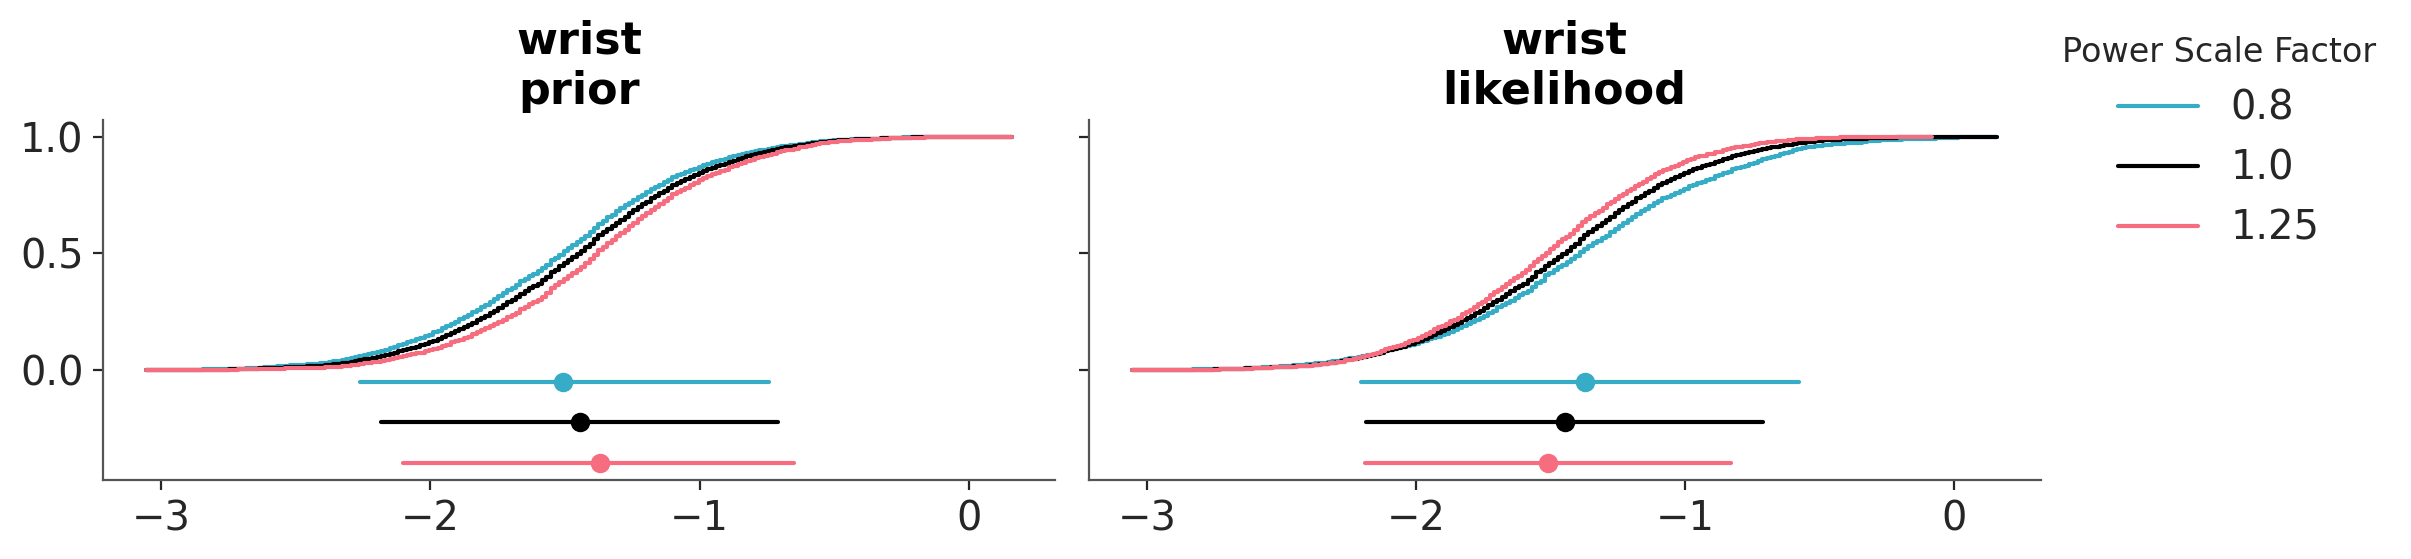

In [5]:
az.plot_psense_dist(
    dt_bf_00,
    var_names=["wrist"],
    kind="ecdf",
);

We can also use the `plot_psense_quantities` function to display quantities of interest like the mean, median, standard deviation, etc. We can then evaluate how much the quantities of interest change when we perturb the prior and likelihood. To get a reference for the relative effect size of the perturbations the function also shows the ±2 Monte Carlo standard errors (MCSE) of the base posterior quantity. We can see that power-scaling the prior and likelihood pulls the posterior mean in opposite directions. This suggests there might be a potential mismatch or conflict between the prior and the likelihood.

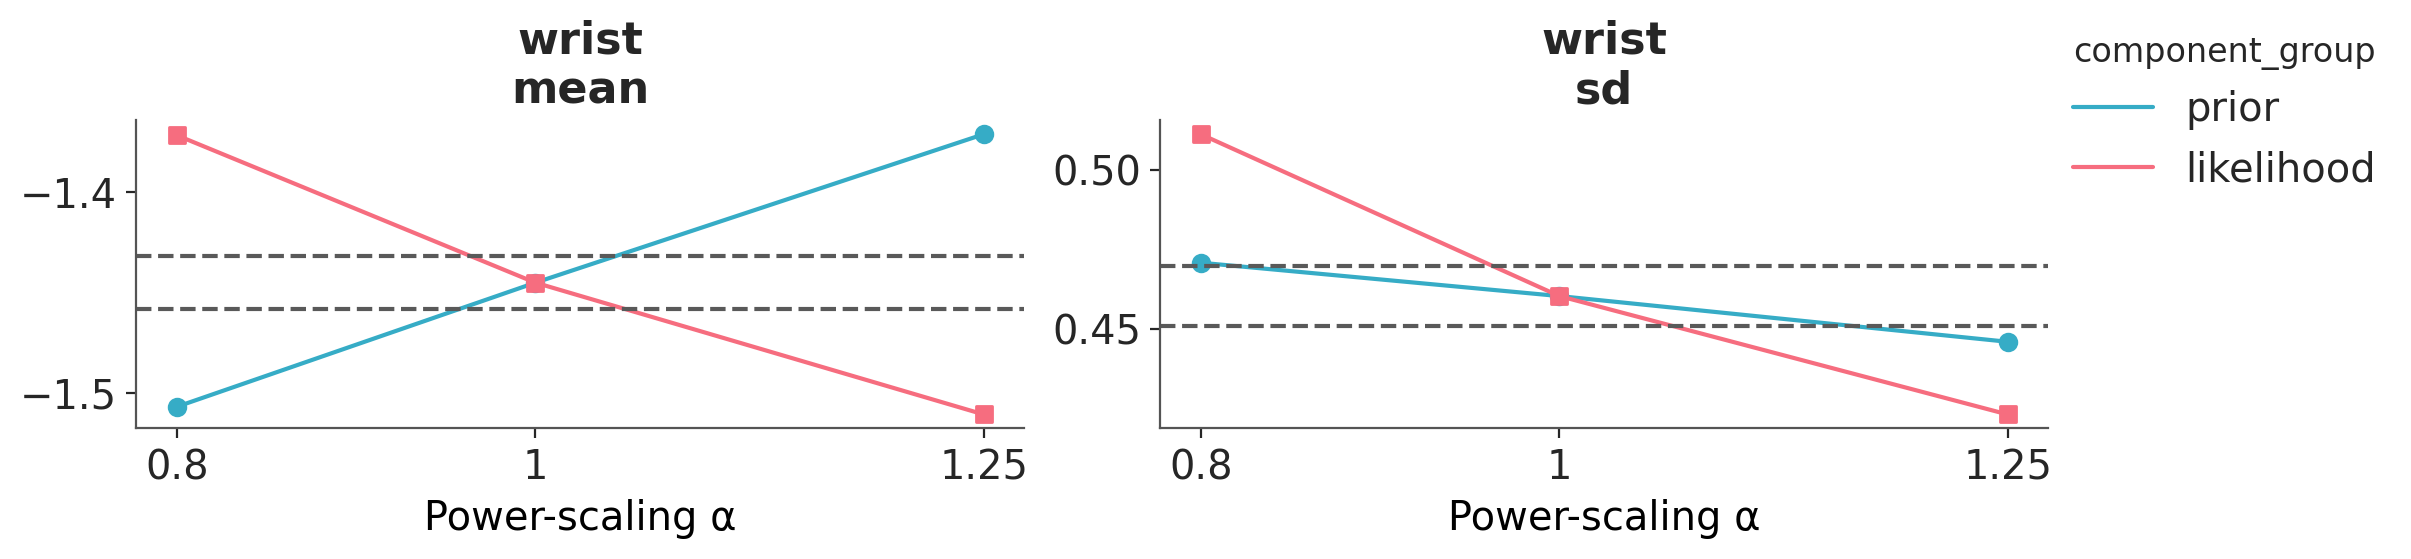

In [6]:
az.plot_psense_quantities(dt_bf_00, var_names=["wrist"]);

### Adjusting the prior


As there is prior sensitivity arising from prior-data conflict, which is unexpected and unintentional as our priors were chosen to be weakly informative, we consider modifying the priors. On inspecting the raw data, we see that although the predictor variables are all measured on similar scales, the variances of the variables differ substantially. For example, the variance of wrist circumference is 0.83, while the variance of abdomen is 102.65. This leads to our chosen prior to be unintentionally
informative for some regression coefficients, including wrist, while being weakly informative for others

Let see what happens if we use the default priors computed by Bambi, which are designed to be very weakly informative.

In [7]:
model_bf_01 = bmb.Model(f"siri ~ {' + '.join(covars)}", data=body_fat)
dt_bf_01 = model_bf_01.fit(random_seed=SEED)
model_bf_01.compute_log_likelihood(dt_bf_01)
model_bf_01.compute_log_prior(dt_bf_01)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, abdomen, age, ankle, biceps, chest, forearm, height, hip, knee, neck, thigh, weight, wrist]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 7 seconds.


Now we can perform the sensitivity analysis again. We can see that we managed to remove the warning!

In [8]:
az.psense_summary(dt_bf_01, var_names=["~mu"], round_to=2)

,prior,likelihood,diagnosis
sigma,0.0,0.21,✓
Intercept,0.0,0.10,✓
abdomen,0.0,0.09,✓
age,0.0,0.11,✓
ankle,0.0,0.11,✓
biceps,0.0,0.09,✓
chest,0.0,0.11,✓
forearm,0.0,0.10,✓
height,0.0,0.09,✓
hip,0.0,0.10,✓


We can see that after changing the prior, the posterior mean for `wrist` changes from -1.45 to -1.86, indicating that the base prior was indeed unintentionally informative and in conflict with the data, pulling the estimate towards zero. 

As previously, we can also evaluate the effect of power-scaling visually with the function `plot_psense_dist`. From @fig-posterior-sensitivity_bf_01 we can see a better overlap between the posterior distributions, compared to the original prior.


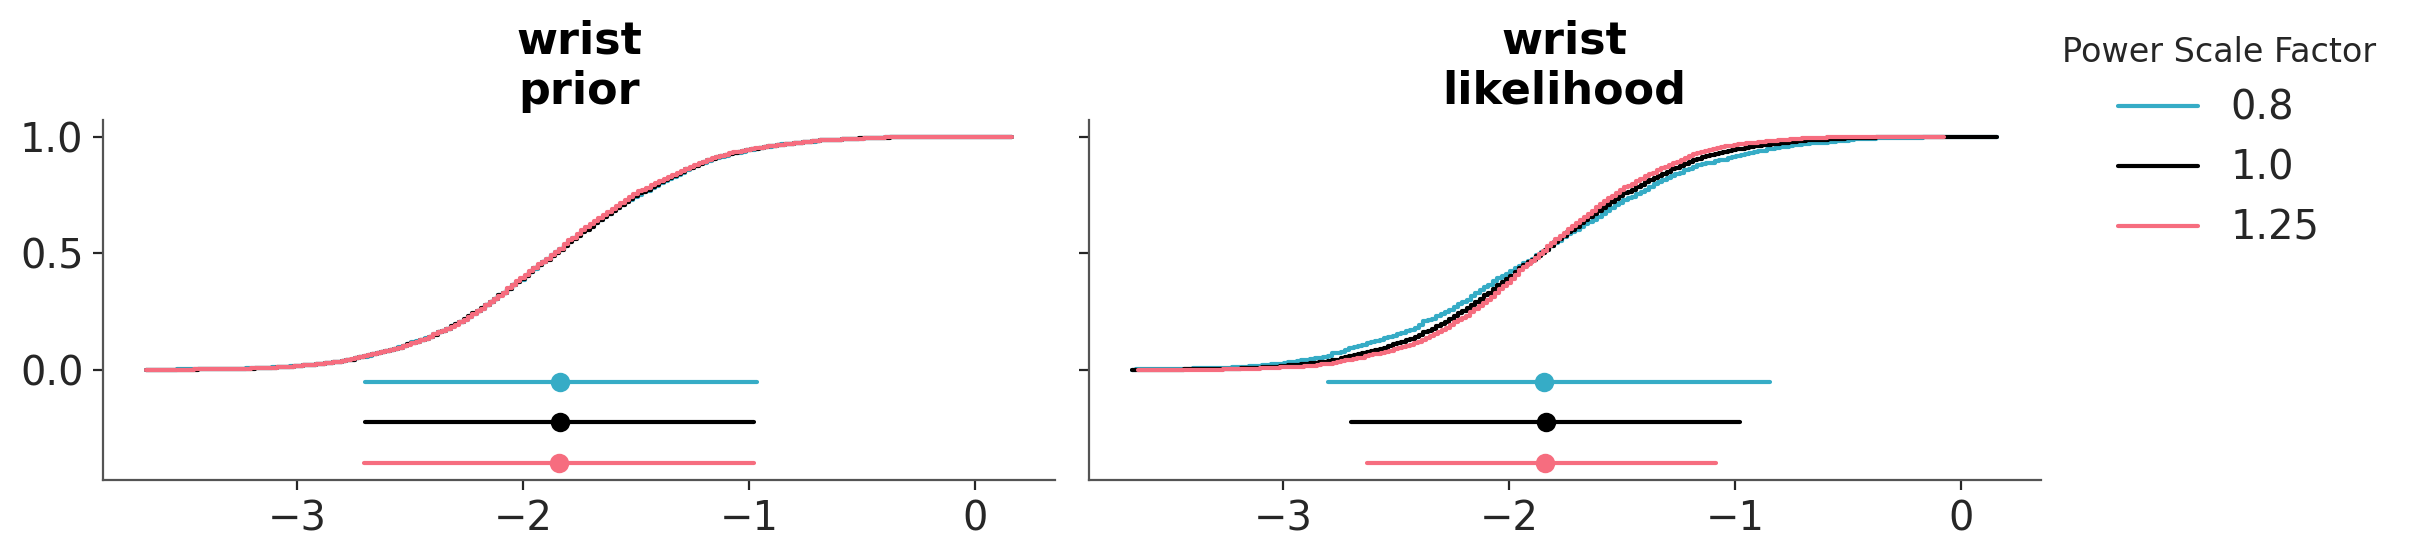

In [9]:
az.plot_psense_dist(
    dt_bf_01,
    var_names=["wrist"],
    kind="ecdf",
);

In terms or the mean for `wrist`, we can see that there is no longer prior or likelihood sensitivity, indicating no prior-data conflict. For the standard deviation, likelihood sensitivity remains, indicating that the likelihood is informative.

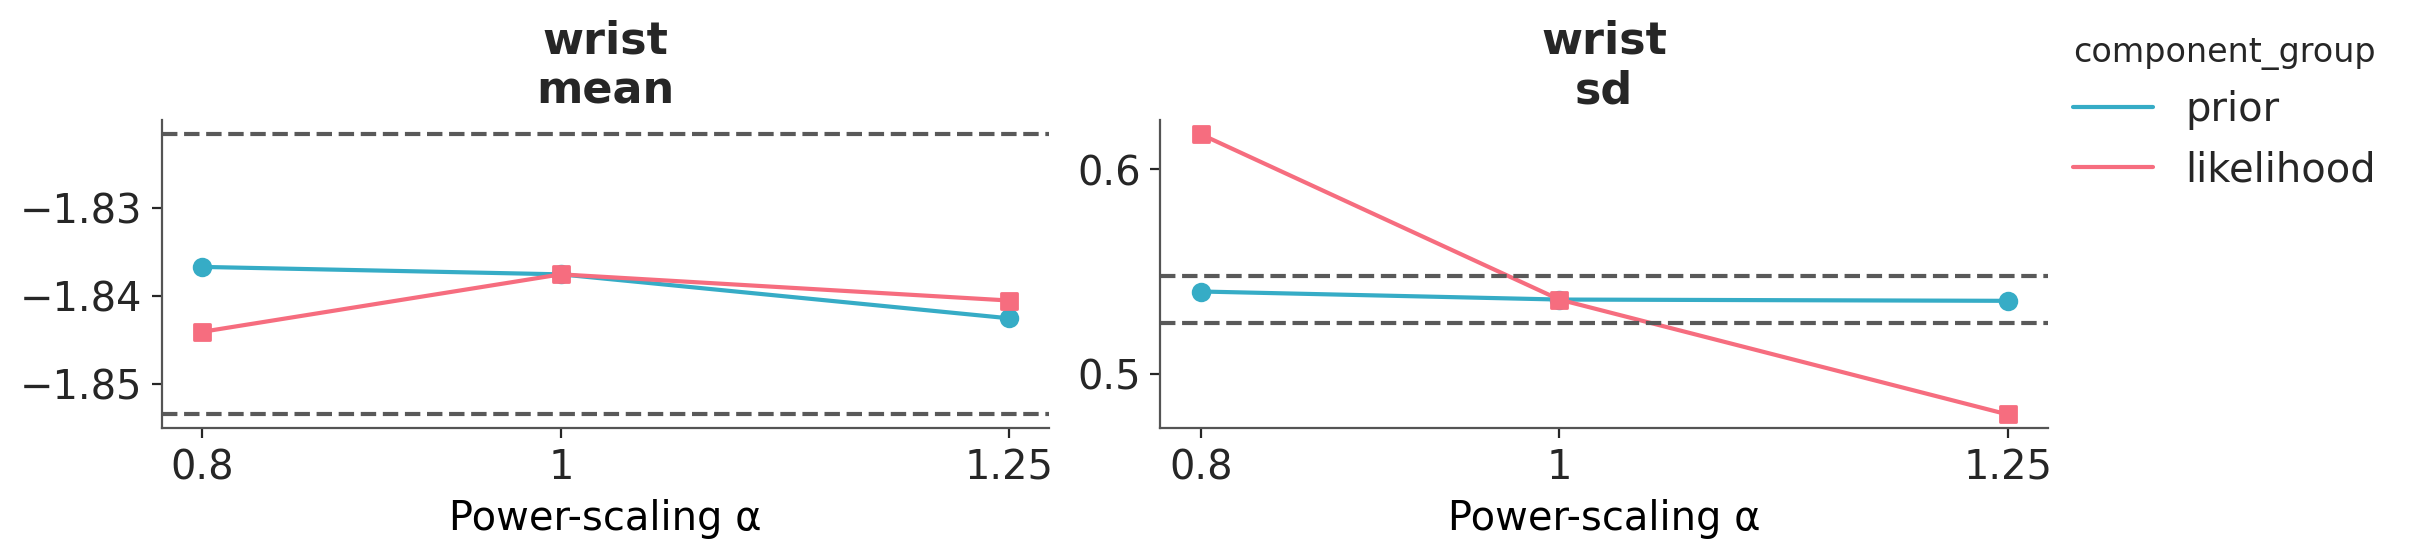

In [10]:
az.plot_psense_quantities(dt_bf_01, var_names=["wrist"]);

In this example, we have “thrown the baby out with the bathwater” by switching entirely from custom priors to default ones. In a more realistic scenario, you might instead want to change the priors to better reflect your domain expertise, rather than simply accepting the defaults. After all, for some reason, you chose those priors in the first place! But the focus of the example is to illustrate the process of prior sensitivity analysis and how to interpret the results.

To help clarify how to use this (or other tools for prior sensitivity analysis), here are a few key points:

* **Default priors aren't always the best**, but they’re often a reasonable starting point.
* **Whenever you're using priors, it's a good idea to check for prior sensitivity.** The defaults provided by Bambi tend to be vague, so prior-data conflict is unlikely, but it’s still possible for some models.
* **If you do detect a prior-data conflict, consider the following:**

  * Adjust the priors to make them less informative, unless you have a strong reason to keep them as is. Remember, **you** are responsible for your model, not some algorithm!
  * If you modify the priors, base those changes on domain knowledge, or statistical knowledge. Tweaking priors just to make diagnostics "look good" is a bad practice. This principle applies to all forms of prior sensitivity checks, not just the one shown here, and to other diagnostics as well (e.g., MCMC sampling diagnostics). Diagnostics alert us of potential problems, but prior specification (and other modeling choices) should be guided by your understanding of the problem.

## Non-interpretable parameters and derived quantities

In many cases, instead of looking at the posterior distribution of the model parameters, we will be interested in derived quantities. For instance, predictive performance measures, such as the Bayesian R², the RMSE or the log-score. Or maybe predictions, including predictions evaluated at specific values of the predictors, like the median of one or more predictors.

Evaluating the sensitivity of derived quantities can be useful in at least two scenarios:

1. When the model parameters are not directly interpretable. For example, the coefficient for splines are not only not directly interpretable, they are not relevant *per se*, they are just an "intermediate step" to get a smooth and flexible function. The same applies to Gaussian processes (GPs), Bayesian additive regression trees (BART), polynomials, etc. If the parameters are not directly interpretable, we can exclude them from these sensitivity checks, and instead focus on the derived quantities. 

2. When we are interested in a quantity that is more relevant or easier to explain to our audience. Sometimes we don't care about the parameters of a model, irrespective of whether they are interpretable or not. This could happen if we are focused on a quantity that is of interest or easier to interpret for our audience, like the R². This could also be the case when our focus is on predictions. If those cases, we may decide to focus on the sensitivity checks for the derived quantities and, if they are ok, ignore the ones for the model parameters, even if they are interpretable. If the checks for the derived quantities are not ok, we may need to go back and check the model parameters, in particular if they are interpretable.

## Computing derived quantities


Let's illustrate this with an example. We will use the same model we used in the previous section, but instead of looking at the posterior distribution of the parameters, we will focus on the following derived quantities:

* Predictions at the median, minimum and maximum values of each covariate.
* The Bayesian R².
* The log-score. This is the sum of the log-likelihood over all observations.

We are going to start by computing predictions at `new_data`. In this case, we will use the median, min, and max values of each covariate. For your particular use case, you may want to use different values, like quantiles of any other specific values of interest.

In [11]:
new_data = pd.DataFrame(
    [body_fat[covars].min(), body_fat[covars].median(), body_fat[covars].min()],
    index=["min", "median", "max"],
)

new_pred = model_bf_01.predict(
    dt_bf_01, kind="response", data=new_data, inplace=False
).posterior_predictive["siri"]

Even when these are predictions we are going to manually add them as posterior quantities, so that we can use the same functions as before to visualize and analyze them.

In [12]:
dt_bf_01.posterior["at_min"] = new_pred.sel(__obs__=0, drop=True)
dt_bf_01.posterior["at_median"] = new_pred.sel(__obs__=1, drop=True)
dt_bf_01.posterior["at_max"] = new_pred.sel(__obs__=2, drop=True)

We can ask ArviZ, to compute the Bayesian R² for us, as long as we provide a DataTree with both observed and predicted data. So, let's compute the predictions.

In [13]:
model_bf_01.predict(dt_bf_01, kind="response")

Then we compute the Bayesian R². And we add it to the posterior.

In [14]:
r2_da = az.ndarray_to_dataarray(
    az.bayesian_r2(dt_bf_01, pred_mean="mu", scale="sigma", summary=False).reshape(4, 1000),
    var_name="r2",
)
dt_bf_01.posterior["r2_score"] = r2_da

To compute the log-score we just sum the poin-twise log-likelihood evaluations along the observations. In other words we compute one log-likelihood value per MCMC step.

In [15]:
dt_bf_01.posterior["log_score"] = dt_bf_01.log_likelihood.sum("__obs__")["siri"]

Once we have added the derived quantities we can call `psense_summary` (or the others `psense_*` functions) as usual:

In [16]:
az.psense_summary(dt_bf_01, var_names=["r2_score", "log_score", "at_min", "at_median", "at_max"])

,prior,likelihood,diagnosis
r2_score,0.001,0.152,✓
log_score,0.002,0.658,✓
at_min,0.000,0.033,✓
at_median,0.000,0.029,✓
at_max,0.000,0.026,✓


We see no signs of data-conflict or likelihood noninformativity, we can visually check this, but given these values we should expect the distributions of the derived quantities to very similar across the different priors.

In [17]:
%load_ext watermark
%watermark -n -u -v -iv -w

Last updated: Thu, 02 Jul 2026

Python implementation: CPython
Python version       : 3.14.4
IPython version      : 9.12.0

arviz : 1.2.0
bambi : 0.18.1.dev6+ga9b7ef490.d20260701
pandas: 3.0.2

Watermark: 2.6.0

